# Stress state within a prestine ground glacier.

In this code, we'll gain insight into the behaviour of  pristine glaciers that are land terminating and ocean terminating. Mimicking the conditions relevant to grounded glaciers, a free slip condition is applied to the bottom surface, restraining the displacement in the vertical direction. The normal component of the displacement field at the far left edge is restrained to prevent rigid body motion in the horizontal direction. The top surface, representing the atmosphere–ice interface, is defined as a free boundary.

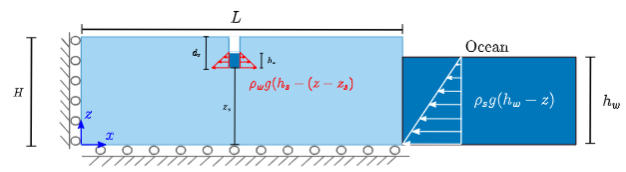

## Step 1: Preprocessing
- Define units: N, m
- Prepare the design basis report

## Step 2: Importing Necessary Libraries

In [200]:
from dolfin import *
import ufl
from helpers import *
from matplotlib import pyplot as plt
%matplotlib inline

## Step 3: Loading the Mesh

In [201]:
# mesh = Mesh()
# with XDMFFile("mesh/ice.xdmf") as infile:
#     infile.read(mesh)

mesh = RectangleMesh(Point(0, 0), Point(500, 125), 500, 125)

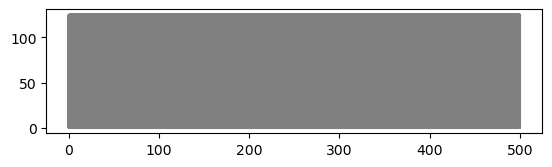

In [202]:
plot(mesh)

## Step 4: Preparing the sets

In [203]:
support_left = CompiledSubDomain("on_boundary && near(x[0], 0.0, tol)", tol=1e-14)
support_bottom = CompiledSubDomain("on_boundary && near(x[1],0.0, tol)", tol=1e-14)
load_right = CompiledSubDomain("on_boundary && x[1]<= 62.5 && x[0]==500")

mf_line = MeshFunction("size_t", mesh, 1)
load_right.mark(mf_line, 1)

ds = Measure("ds")(subdomain_data=mf_line)

## Step 5: Preparing output file

In [204]:
xdmf = XDMFFile("output/solution.xdmf")
xdmf.parameters["functions_share_mesh"] = True
xdmf.parameters["rewrite_function_mesh"] = False
xdmf.parameters["flush_output"] = True

## Step 6: Defining  spaces

In [205]:
FDG0 = FunctionSpace(mesh, "DG", 0)
TDG0 = TensorFunctionSpace(mesh, "DG", 0)
V1 = VectorFunctionSpace(mesh, "CG", 1)

## Step 7: Define functions

In [206]:
u, v = TrialFunction(V1), TestFunction(V1)
u_sol = Function(V1, name="disp")
stress_xx, cdf = Function(FDG0, name="sigma_xx"), Function(FDG0, name="cdf")

## Step 8: Material Model

In [207]:
g = 9.81
rho_sea = 1020 * g
E0_ice = 9500e6
nu_ice = 0.35
rho_i_ice = 917 * g
sigma_c_ice = 0.1185e6

In [208]:
ice = MaterialModel(E0_ice, nu_ice, rho_i_ice, sigma_c_ice)

## Step 9: Define supports

In [209]:
bc_sp_x = DirichletBC(V1.sub(0), Constant(0.0), support_left)
bc_sp_x2 = DirichletBC(V1.sub(1), Constant(0.0), support_bottom)
bc_u = [bc_sp_x, bc_sp_x2]

## Step 10: Define Loads


In [ ]:
# t = Expression(("-(rho_sea*(125/2 -x[1]))", 0), rho_sea=rho_sea, degree=1)
t = Expression(("(125/2 - x[1] >= 0 ? - rho  * (125/2 - x[1]) : 0.0)", 0), rho=rho_sea, degree=1)

# t = Constant((0, 0))
f = Constant((0, -ice.rho))

## Step 11: Define the problem

In [211]:
a = inner(ice.stress(u), ice.strain(v)) * dx
L = dot(f, v) * dx + dot(t, v) * ds(1)

## Step 12: Solve 

In [212]:
solve(a == L, u_sol, bc_u)

Solving linear variational problem.


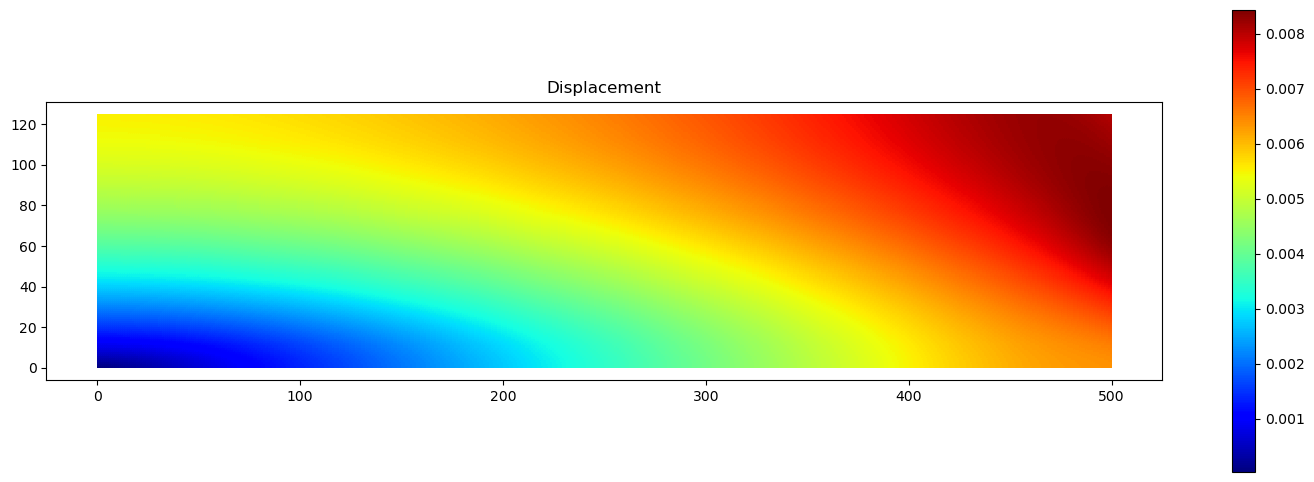

In [213]:
plt.figure(figsize=(18, 6))
c = plot(u_sol, mode="displacement", title="Displacement", cmap="jet")
plt.colorbar(c)  # Adds the colorbar
plt.show()

## Step 13: Post processing

In [214]:
stress_xx.assign(project(ice.stress(u_sol)[0,0]/1e6, FDG0)) # N/m2 -> MPa
cdf.assign(project(ice.get_crack_driving_force(u_sol), FDG0))

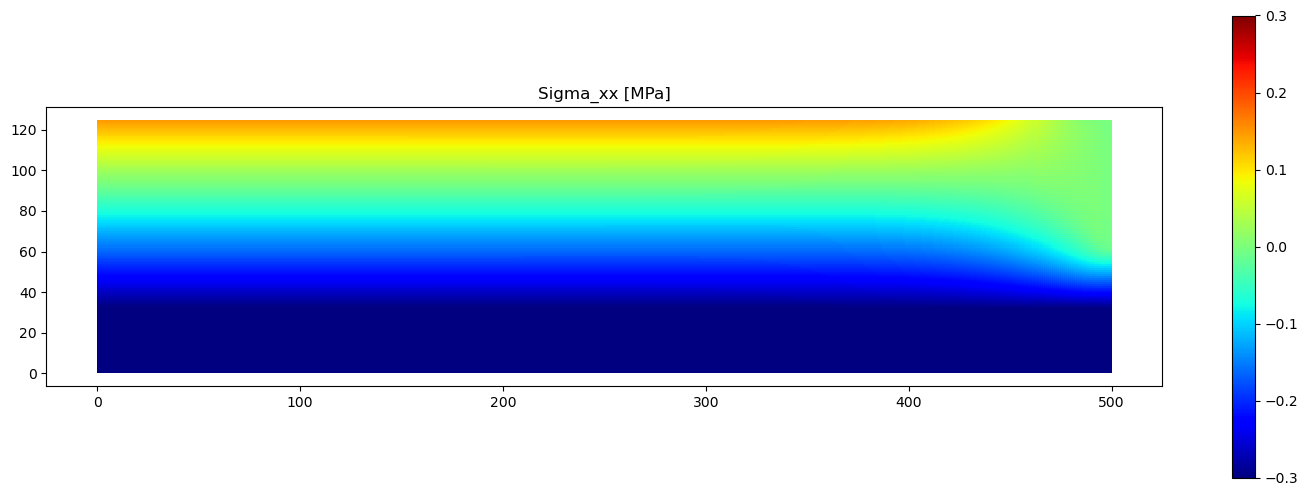

In [215]:
plt.figure(figsize=(18, 6))
c = plot(stress_xx, title="Sigma_xx [MPa]", cmap="jet")
c.set_clim(-0.3, 0.3)
plt.colorbar(c)
plt.show()

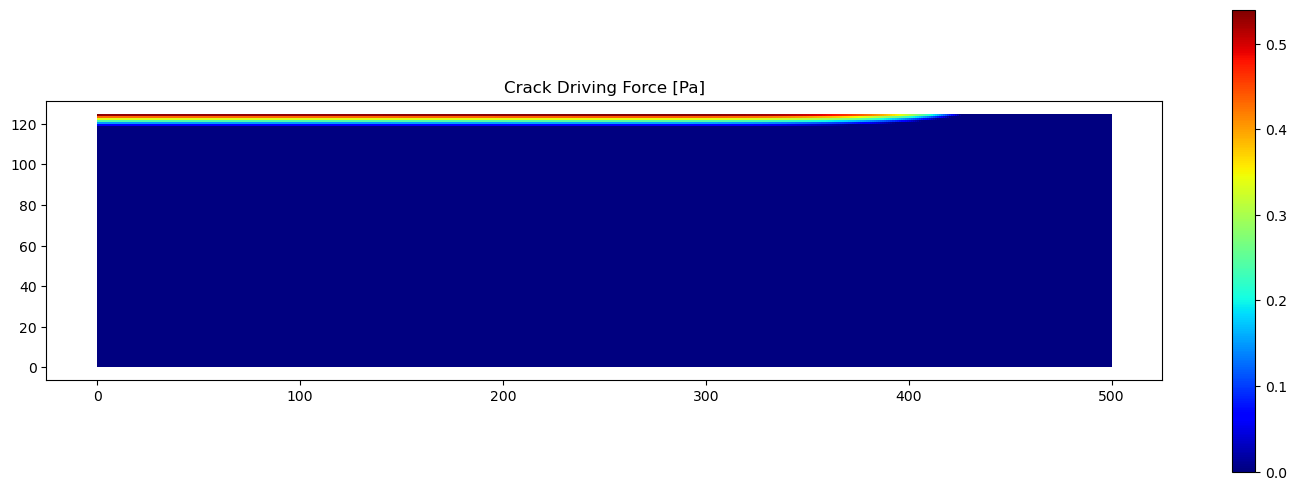

In [216]:
plt.figure(figsize=(18, 6))
c = plot(cdf, title="Crack Driving Force [Pa]", cmap="jet")
plt.colorbar(c)  # Adds the colorbar
plt.show()

In [217]:
xdmf.write(u_sol,0)
xdmf.write(stress_xx,0)
xdmf.write(cdf,0)
xdmf.close()

In [218]:
cdf.vector().max()

0.5401137235107878

In [219]:
u_sol.vector().min(), u_sol.vector().max()

(-0.005594851237027282, 0.007393524860404741)

In [220]:
stress_xx.vector().min(), stress_xx.vector().max()

(-0.6148348233008676, 0.14705879546101808)

In [226]:
from dolfin import *
import ufl
from helpers_3d import *

Lx = 500.0
Ly = 750.0
Lz = 125.0

nx = 50
ny = 75
nz = 12

mesh = BoxMesh(
    Point(0.0, 0.0, 0.0),
    Point(Lx, Ly, Lz),
    nx,
    ny,
    nz,
)

tol = 1e-10

support_left = CompiledSubDomain(
    "on_boundary && near(x[0], 0.0, tol)",
    tol=tol,
)

support_bottom = CompiledSubDomain(
    "on_boundary && near(x[2], 0.0, tol)",
    tol=tol,
)

support_front = CompiledSubDomain(
    "on_boundary && near(x[1], 0.0, tol)",
    tol=tol,
)

support_back = CompiledSubDomain(
    "on_boundary && near(x[1], Ly, tol)",
    Ly=Ly,
    tol=tol,
)

load_right = CompiledSubDomain(
    "on_boundary && near(x[0], Lx, tol) && x[2] <= water_height",
    Lx=Lx,
    water_height=0.5 * Lz,
    tol=tol,
)

mf_surface = MeshFunction(
    "size_t",
    mesh,
    mesh.topology().dim() - 1,
    0,
)

load_right.mark(mf_surface, 1)

ds = Measure(
    "ds",
    domain=mesh,
    subdomain_data=mf_surface,
)

xdmf = XDMFFile("output/solution_3d.xdmf")

xdmf.parameters["functions_share_mesh"] = True
xdmf.parameters["rewrite_function_mesh"] = False
xdmf.parameters["flush_output"] = True

FDG0 = FunctionSpace(mesh, "DG", 0)
TDG0 = TensorFunctionSpace(mesh, "DG", 0)
V1 = VectorFunctionSpace(mesh, "CG", 1)

u = TrialFunction(V1)
v = TestFunction(V1)

u_sol = Function(V1, name="disp")

stress_xx = Function(FDG0, name="sigma_xx")
cdf = Function(FDG0, name="cdf")

g = 9.81

rho_sea = 1020.0 * g

E0_ice = 9500e6
nu_ice = 0.35

rho_i_ice = 917.0 * g

sigma_c_ice = 0.1185e6

ice = MaterialModel(
    E0_ice,
    nu_ice,
    rho_i_ice,
    sigma_c_ice,
)

bc_left = DirichletBC(
    V1.sub(0),
    Constant(0.0),
    support_left,
)

bc_back = DirichletBC(
    V1.sub(1),
    Constant(0.0),
    support_back,
)

bc_front = DirichletBC(
    V1.sub(1),
    Constant(0.0),
    support_front,
)

bc_z = DirichletBC(
    V1.sub(2),
    Constant(0.0),
    support_bottom,
)

bc_u = [
    bc_left,
    bc_back,
    bc_front,
    bc_z,
]

t = Constant((0.0, 0.0, 0.0))
# t = Expression(("(125/4 - x[2] >= 0 ? - rho  * (125/4 - x[2]) : 0.0)", 0, 0), rho=rho_sea, degree=1)

# t = Expression(("-(rho_sea*(125/2 -x[1]))", 0, 0), rho_sea=rho_sea, degree=1)

f = Constant(
    (
        0.0,
        0.0,
        -ice.rho,
    )
)

a = inner(
    ice.stress(u),
    ice.strain(v),
) * dx

L = (
    dot(f, v) * dx
    + dot(t, v) * ds(1)
)

solve(
    a == L,
    u_sol,
    bc_u,
    solver_parameters={
        "linear_solver": "cg",
        "preconditioner": "ilu",
    },
)

stress_xx.assign(
    project(
        ice.stress(u_sol)[0, 0] / 1e6,
        FDG0,
    )
)

cdf.assign(
    project(
        ice.get_crack_driving_force(u_sol),
        FDG0,
    )
)

xdmf.write(u_sol, 0.0)
xdmf.write(stress_xx, 0.0)
xdmf.write(cdf, 0.0)

xdmf.close()

print("Maximum crack driving force:", cdf.vector().max())

print(
    "Sigma_xx range [MPa]:",
    stress_xx.vector().min(),
    stress_xx.vector().max(),
)

Solving linear variational problem.
Maximum crack driving force: 5.526709854822384
Sigma_xx range [MPa]: -0.27829412877606957 0.28853777960111987


In [222]:
u_sol.vector().min(), u_sol.vector().max()

(-0.028932297144974136, 0.18647323947383648)